# Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import seaborn as sns
from pathlib import Path


# Pobieramy ścieżkę do folderu wyżej (czyli głównego folderu projektu)
project_root = os.path.abspath('..')

# Dodajemy ją do listy ścieżek, w których Python szuka modułów
if project_root not in sys.path:
    sys.path.append(project_root)
    
print(f"Dodano ścieżkę główną: {project_root}")

Dodano ścieżkę główną: /mnt/FC3E32CE3E3281A6/Users/Stanislav/github_desktop_wd/mamba-joint-distribution-finance


# Loading data

In [ ]:
path1 = '../data/raw/djia29/AAPL.csv'
path2 = '../data/raw/djia29/AMZN.csv'

with open(path1, 'r') as f:
    data_raw1 = pd.read_csv(f, index_col='date', parse_dates=['date'], skiprows = [1])

with open(path2, 'r') as f:
    data_raw2 = pd.read_csv(f, index_col='date', parse_dates=['date'], skiprows = [1])

,close,volume,open,high,low
date,,,,,
2018-08-13,208.87,25864510.0,207.70,210.952,207.70
2018-08-10,207.53,24592460.0,207.36,209.100,206.67
2018-08-09,208.88,23389530.0,207.28,209.780,207.20
2018-08-08,207.25,22493750.0,206.05,207.810,204.52
2018-08-07,207.11,25525650.0,209.32,209.500,206.76


In [ ]:
data1 = data_raw1.copy()
data2 = data_raw2.copy()

data1 = data1.astype(float)
data1 = data1.sort_index(ascending=True)

data2 = data2.astype(float)
data2 = data2.sort_index(ascending=True)

,close,volume,open,high,low
date,,,,,
2008-08-14,25.6171,177684343.0,25.4757,25.7786,25.4057
2008-08-15,25.1057,176996663.0,25.5771,25.6786,25.0071
2008-08-18,25.0557,137832351.0,25.0814,25.4014,24.8314
2008-08-19,24.7900,153915766.0,24.9343,25.2957,24.5443
2008-08-20,25.1200,126718798.0,24.9676,25.2771,24.8014


In [ ]:
data1['returns'] = data1['close'].pct_change()
data1['log_returns'] = np.log(data1['close'] / data1['close'].shift(1))
data1.head()

,close,volume,open,high,low,returns,log_returns
date,,,,,,,
2008-08-14,25.6171,177684343.0,25.4757,25.7786,25.4057,NaN,NaN
2008-08-15,25.1057,176996663.0,25.5771,25.6786,25.0071,-0.019963,-0.020165
2008-08-18,25.0557,137832351.0,25.0814,25.4014,24.8314,-0.001992,-0.001994
2008-08-19,24.7900,153915766.0,24.9343,25.2957,24.5443,-0.010604,-0.010661
2008-08-20,25.1200,126718798.0,24.9676,25.2771,24.8014,0.013312,0.013224


In [36]:
from scipy.stats import gennorm, rankdata

def normalize_to_uniform(df: pd.DataFrame, column: str = 'log_returns', method: str = 'gennorm') -> pd.DataFrame:
    """
    Normalizuje wybraną kolumnę (np. log_returns) do rozkładu jednorodnego [0, 1].
    
    Parametry:
    - method: 'gennorm' (Parametryczny - Uogólniony Rozkład Normalny) 
              lub 'ecdf' (Nieparametryczny - Empiryczna Dystrybuanta)
    """
    df_clean = df.copy()
    
    # Zabezpieczenie: pracujemy tylko na danych bez NaN (pierwszy wiersz z log_returns)
    valid_data = df_clean[column].dropna()
    
    if method == 'gennorm':
        # 1. Dopasowanie modelu (fitting): Szukamy idealnego kształtu, średniej i odchylenia
        beta, loc, scale = gennorm.fit(valid_data)
        
        # 2. Mapowanie do [0,1] przy użyciu Dystrybuanty (CDF)
        uniform_data = gennorm.cdf(valid_data, beta, loc=loc, scale=scale)
        
    elif method == 'ecdf':
        # Alternatywa: po prostu sortujemy dane i przypisujemy im rangi.
        # Dzielimy przez (N+1), aby uniknąć idealnego 1.0, co czasem psuje wielomiany.
        uniform_data = rankdata(valid_data) / (len(valid_data) + 1)
        
    else:
        raise ValueError("Metoda musi być 'gennorm' lub 'ecdf'")
        
    # Tworzymy nową kolumnę z gotowymi danymi pod HCR
    df_clean.loc[valid_data.index, 'uniform_returns'] = uniform_data
    
    return df_clean

Dopasowane parametry: beta=0.9767, loc=-0.0009, scale=0.0124


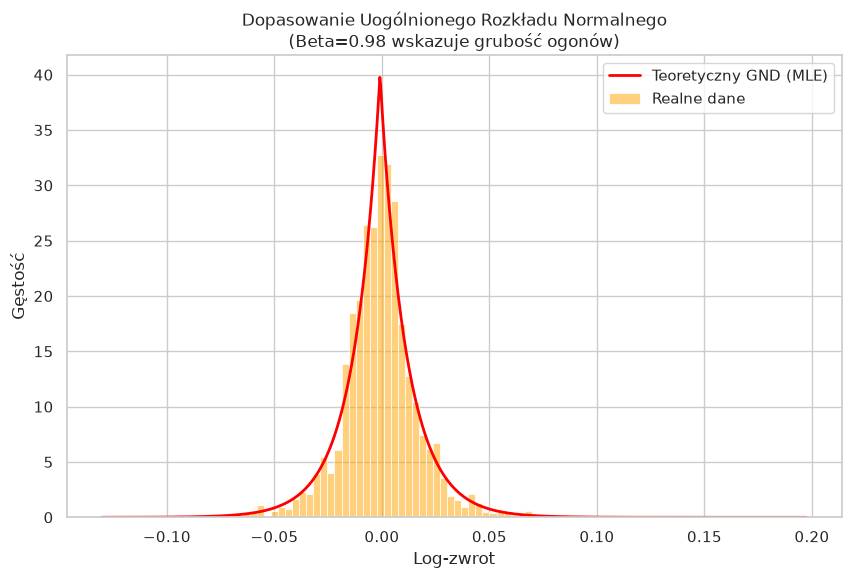

In [ ]:
from scipy.stats import gennorm

def plot_theoretical_vs_empirical(df, column='log_returns'):
    data = df[column].dropna()
    
    # 1. Dopasowanie parametrów (MLE)
    beta, loc, scale = gennorm.fit(data)
    print(f"Dopasowane parametry: beta={beta:.4f}, loc={loc:.4f}, scale={scale:.4f}")
    
    # 2. Rysowanie histogramu
    plt.figure(figsize=(10, 6))
    sns.histplot(data, bins=100, stat='density', color='orange', alpha=0.5, label='Realne dane')
    
    # 3. Rysowanie teoretycznej krzywej GND (Uogólniony Rozkład Normalny)
    # Tworzymy oś x dla krzywej
    x_range = np.linspace(data.min(), data.max(), 1000)
    pdf_theoretical = gennorm.pdf(x_range, beta, loc=loc, scale=scale)
    
    plt.plot(x_range, pdf_theoretical, color='red', linewidth=2, label='Teoretyczny GND (MLE)')
    
    plt.title(f'Dopasowanie Uogólnionego Rozkładu Normalnego\n(Beta={beta:.2f} wskazuje grubość ogonów)')
    plt.xlabel('Log-zwrot')
    plt.ylabel('Gęstość')
    plt.legend()
    plt.show()

# Wywołanie dla Twoich danych
plot_theoretical_vs_empirical(df_aapl)

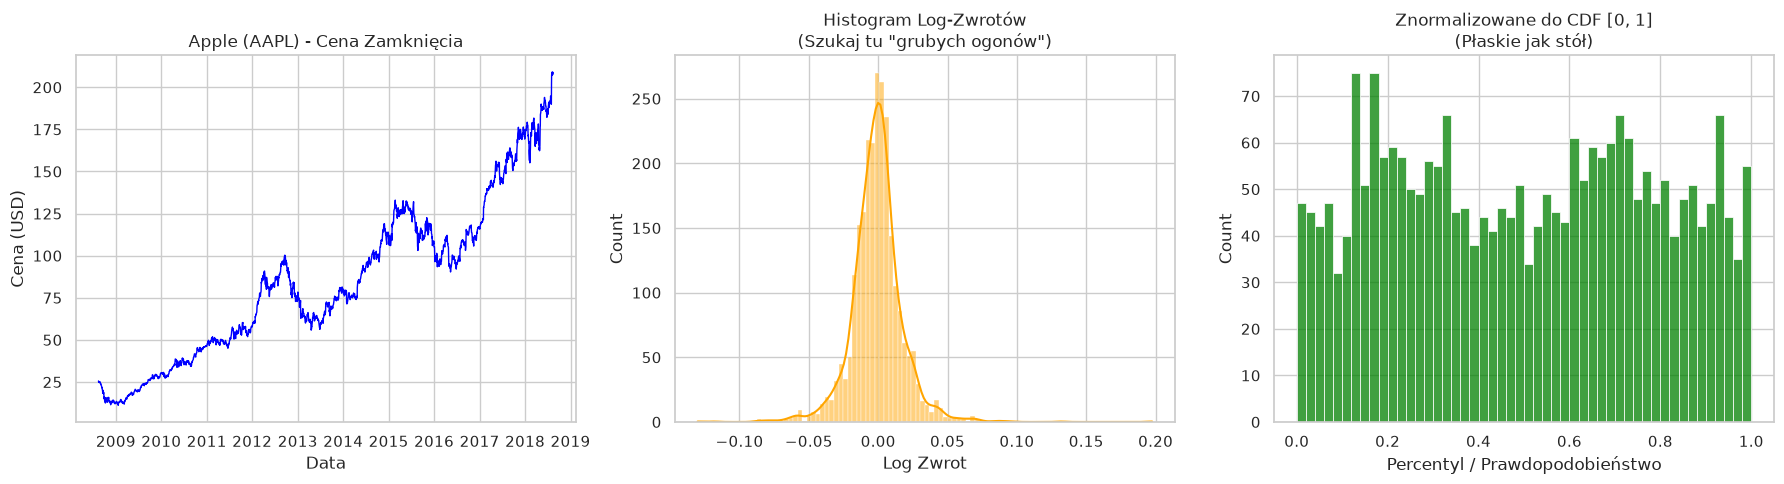

In [ ]:


# 1. NAPRAWA ŚCIEŻEK (aby widział folder src)
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. IMPORTY Z TWOJEGO KODU
from src.data.load_data import load_raw_djia
from src.data.preprocess import calculate_returns, normalize_to_uniform

# 3. USTAWIENIA WYKRESÓW
sns.set_theme(style="whitegrid")

def plot_data_pipeline(df, ticker="Spółka"):
    """Rysuje trzy kroki transformacji danych: Ceny -> Log-Zwroty -> Rozkład Jednorodny."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Wykres 1: Cena
    axes[0].plot(df.index, df['close'], color='blue', linewidth=1)
    axes[0].set_title(f'{ticker} - Cena Zamknięcia')
    axes[0].set_xlabel('Data')
    axes[0].set_ylabel('Cena (USD)')
    
    # Wykres 2: Log-Zwroty
    sns.histplot(df['log_returns'].dropna(), bins=100, kde=True, ax=axes[1], color='orange')
    axes[1].set_title('Histogram Log-Zwrotów\n(Szukaj tu "grubych ogonów")')
    axes[1].set_xlabel('Log Zwrot')
    
    # Wykres 3: Znormalizowane (CDF)
    sns.histplot(df['uniform_returns'].dropna(), bins=50, ax=axes[2], color='green')
    axes[2].set_title('Znormalizowane do CDF [0, 1]\n(Płaskie jak stół)')
    axes[2].set_xlabel('Percentyl / Prawdopodobieństwo')
    
    plt.tight_layout()
    plt.show()

# 4. WYKONANIE PIPELINE'U
# Używamy os.path.join, żeby ścieżka była poprawna niezależnie od systemu
data_path = os.path.join(project_root, 'data', 'raw', 'djia29')
data_dict = load_raw_djia(data_path)

df_aapl = data_dict['AAPL']
df_aapl = calculate_returns(df_aapl)
df_aapl = normalize_to_uniform(df_aapl, column='log_returns', method='gennorm')

# 5. RYSOWANIE
plot_data_pipeline(df_aapl, "Apple (AAPL)")